In [12]:
import cv2                                                     #image read
import numpy as np                                             #numerical calculation
import os                                                      #access data folder
import matplotlib.pyplot as plt                                #for plot
from sklearn.model_selection import train_test_split           #split dataset
from sklearn.svm import SVC                                    #classification model
from sklearn.metrics import accuracy_score                     #check model performance

In [13]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset (2).zip


In [14]:
import zipfile

with zipfile.ZipFile("dataset.zip",'r') as zip_ref:
  zip_ref.extractall("dataset")

In [15]:
data = []
labels = []

dataset_path = "dataset"

for disease in os.listdir(dataset_path):
  disease_folder = os.path.join(dataset_path,disease)

#check folder
  if not os.path.isdir(disease_folder):
    continue

#process only three diseases
  if disease not in ['acne','eczema','psoriasis']:
    continue

  for img_name in os.listdir(disease_folder):

    if not img_name.lower().endswith(('.jpg','.jpeg','.png')):
      continue

    img_path = os.path.join(disease_folder, img_name)
    img = cv2.imread(img_path)

    if img is None:
      print("Dosen't load:", img_path)
      continue

    img = cv2.resize(img, (200,200))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist = cv2.calcHist([hsv],[0,1,2],None,[8,8,8],[0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()

    data.append(hist)
    labels.append(disease)

  print("Image processed:",len(data))

Image processed: 20
Image processed: 40
Image processed: 60


In [16]:
#convert to numpy array
import os
print(os.listdir("dataset"))

['eczema', 'skin-disease-datasaet', 'psoriasis', 'acne']


In [17]:
import numpy as np

X = np.array(data)
y = np.array(labels)

print("Feature shape:",X.shape)
print("Labels shape:",y.shape)

Feature shape: (60, 512)
Labels shape: (60,)


In [18]:
#train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

print("Trainig data:",X_train.shape)
print("Testing data:",X_test.shape)

Trainig data: (48, 512)
Testing data: (12, 512)


In [19]:
#train SVM model
from sklearn.svm import SVC

model = SVC(kernel = 'linear')
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [20]:
#check accuracy
from sklearn.metrics import accuracy_score,classification_report

y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

        acne       1.00      1.00      1.00         6
      eczema       1.00      1.00      1.00         4
   psoriasis       1.00      1.00      1.00         2

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



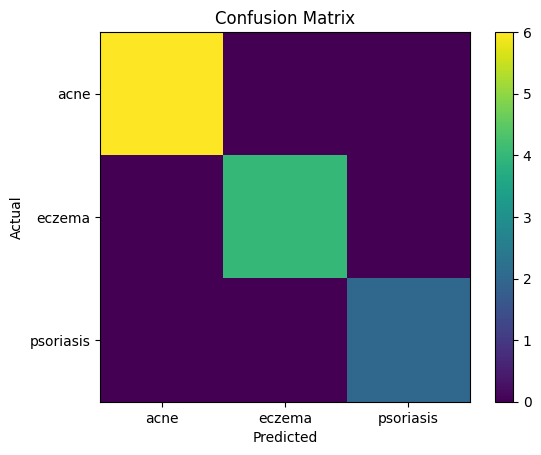

In [21]:
#confusion metrics plot
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = np.unique(y)
plt.xticks(np.arange(len(classes)),classes)
plt.yticks(np.arange(len(classes)),classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

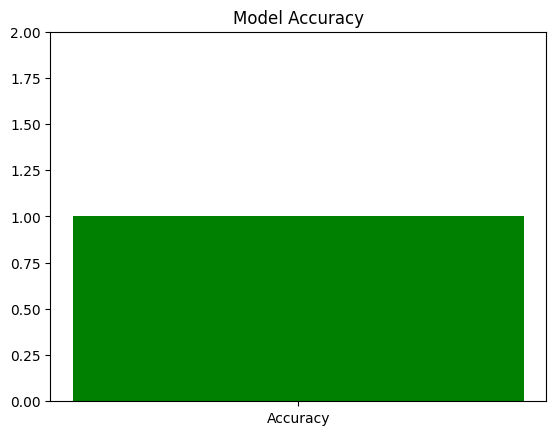

In [25]:
#accuracy bar plot
accuracy = accuracy_score(y_test, y_pred)

plt.figure()
plt.bar(["Accuracy"],[accuracy])
plt.ylim(0,2)
plt.title("Model Accuracy")
plt.show()

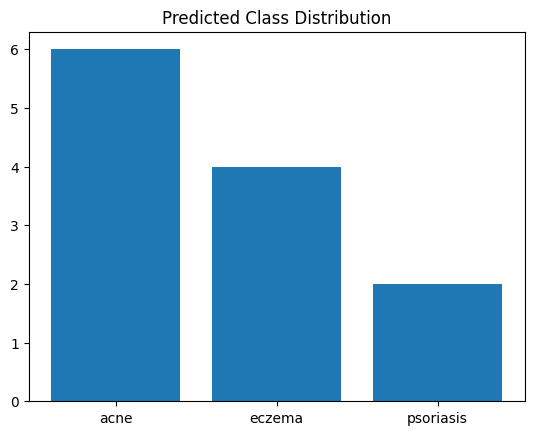

In [27]:
unique, counts = np.unique(y_pred, return_counts=True)

plt.figure()
plt.bar(unique, counts)
plt.title("Predicted Class Distribution")
plt.show()